In [2]:
import numpy as np
import sep

In [3]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [4]:
#extracting the image data from the file
data = fits.getdata('hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits')
#defining mean and standard deviation for calcuations
m, s = np.mean(data), np.std(data)
#changing the data type
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data)

print(bkg.globalback)
print(bkg.globalrms)
bkg_image = bkg.back()

bkg_rms = bkg.rms()

data_sub = data - bkg

#extracting the peaks of brightness as data points.
objects = sep.extract(data_sub, 5, err=bkg.globalrms)
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0, err=bkg.globalrms, gain=1.0)
print(len(objects))

0.0
0.0005398219218477607
2634


In [5]:
for i in range(10):
    print('object {:d}: flux = {:f} +/- {:f}'.format(i, flux[i], fluxerr[i]))

object 0: flux = 0.029248 +/- 0.171045
object 1: flux = 0.081285 +/- 0.285120
object 2: flux = 0.062260 +/- 0.249537
object 3: flux = 0.069449 +/- 0.263548
object 4: flux = 0.039489 +/- 0.198739
object 5: flux = 0.104682 +/- 0.323559
object 6: flux = 0.040038 +/- 0.200116
object 7: flux = 0.053010 +/- 0.230257
object 8: flux = 0.053288 +/- 0.230859
object 9: flux = 0.042534 +/- 0.206259


I found 2653 objects using a threshold of 5

The mean of the data is 1.143

The median of the data is 0.151

The standard deviation of the data is 16.717

The largest outlier has a flux of 807.34 and is 48.21 standard deviations from the mean

2580 data points plotted
54 outliers redacted
We found approximately 2634 stars in the data provided.
The mean of the data is 1.14359203863266.
The median of the data is 0.15093860415276145.
The standard deviation of the data is 16.719825460116628.
The biggest outlier, or in other terms brightest, is a star with a flux of 807.3367860794068,
which is 48.217799639348065 standard deviations from the mean.


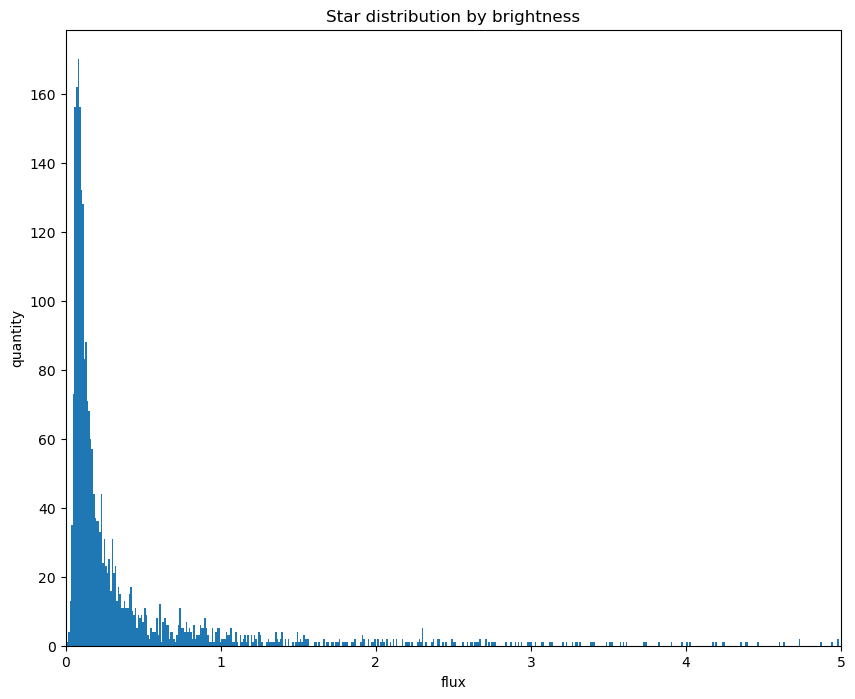

In [6]:
#first, we need to remove the especially bright stars from the histogram, or it messes up the plotting with irrelavent data

culled_flux = []
removed_data = []
for i in flux:
    if (i <= 5)and(i >= 0):
        culled_flux.append(i)
    else:
        removed_data.append(i)
#This code outputs the amount of values of below 0 flux, which are irrelavant to the data

#creating the histogram
plt.hist(culled_flux,bins=500)
plt.xlim(0,5)
plt.title('Star distribution by brightness')
plt.ylabel('quantity')
plt.xlabel('flux')
print(len(culled_flux), 'data points plotted')
print(len(removed_data), 'outliers redacted')

print(f'We found approximately {len(flux)} stars in the data provided.')

print(f'The mean of the data is {np.mean(flux)}.')
print(f'The median of the data is {np.median(flux)}.')
print(f'The standard deviation of the data is {np.std(flux)}.')

print(f'The biggest outlier, or in other terms brightest, is a star with a flux of {max(flux)},')
print(f'which is {(max(flux)-np.mean(flux))/np.std(flux)} standard deviations from the mean.')

This code lays out the previous images of the data being processed in one figure

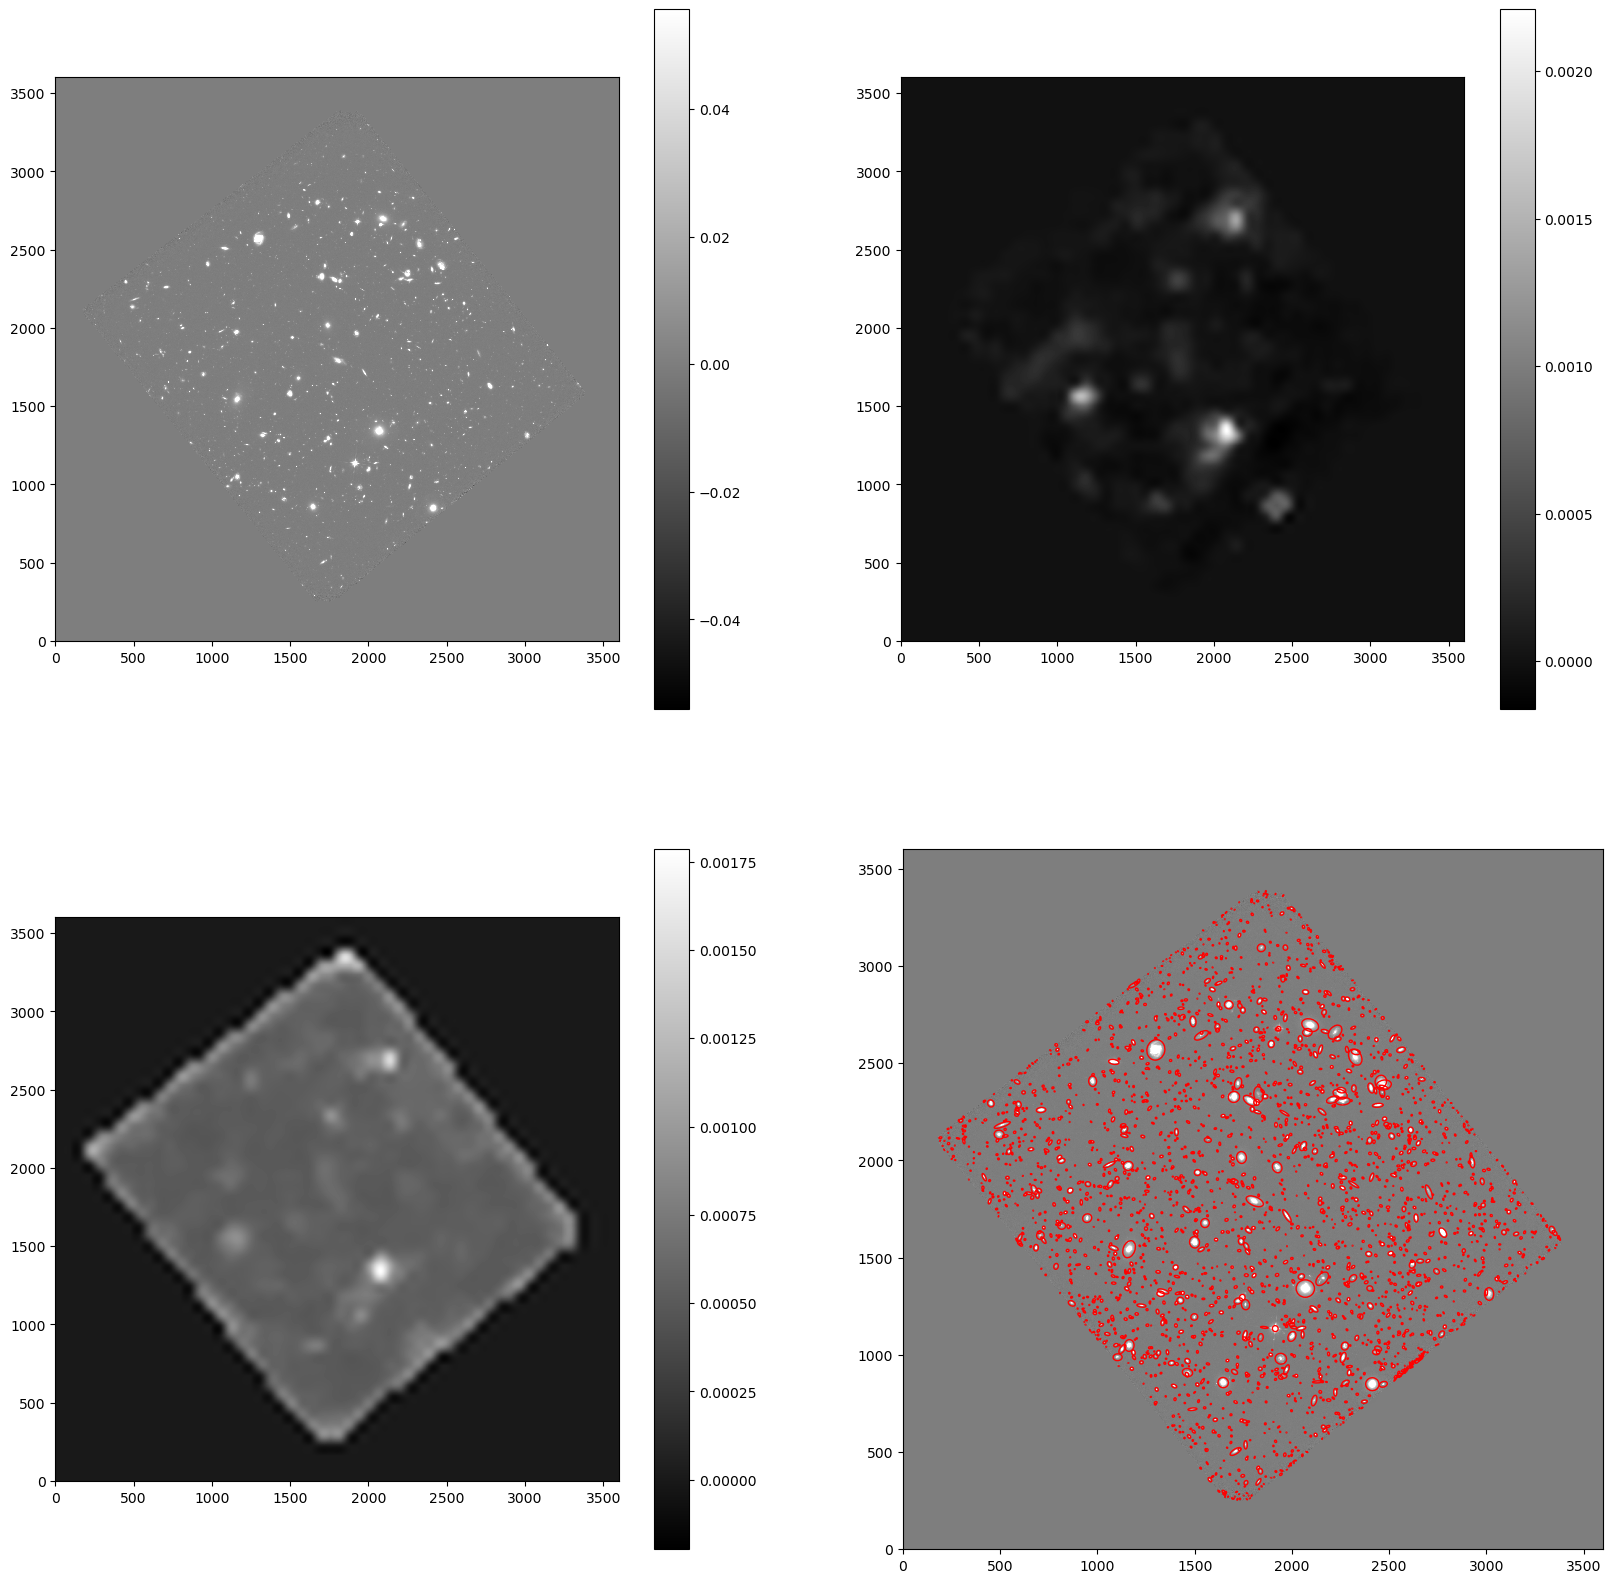

In [8]:
#creating the figure to display the different image/data transformations
fig,ax = plt.subplots(2,2,figsize = (20,20))

im1 = ax[0,0].imshow(data, interpolation='nearest', cmap='gray',vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar(im1, ax=ax[0,0]);

im2 = ax[0,1].imshow(bkg_image, interpolation='nearest',cmap='gray', origin='lower')
fig.colorbar(im2, ax=ax[0,1]);

im3 = ax[1,0].imshow(bkg_rms, interpolation='nearest',cmap='gray',origin='lower')
fig.colorbar(im3, ax=ax[1,0])

m, s = np.mean(data_sub), np.std(data_sub)
im = ax[1,1].imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

from matplotlib.patches import Ellipse

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax[1,1].add_artist(e)

plt.show()